# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_sig_stats

/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

# Single TF perturbation

## Run the analysis

In [2]:
perturbation_mode = 'overexpression' # 'overexpression' # 'natural_aging' for aging clock, 'overexpression' for overexpression perturbation
save_file=f"{save_dir}/perturbation/tf_screen_results_{perturbation_mode}.csv"
cell_types = ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
if True: # single
    from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening
    from ciim.src.common import save_dir
    par = {
        'years': 10,
        'n_donors': 1, # select only one donor for linear models
        'data_type': 'bulk',
        'version': 'v1.0',
        'reg_type': 'ridge',
        'feature_type': 'gene_expression',
        'perturbation_mode': perturbation_mode, # natural_aging, overexpression
        'perturbation_type': 'single',
        'tfs': None,  # None means all TFs
    }
    datasets = ['data12'] #['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese']
     # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
    perturb_rr = wrapper_run_tf_screening(par, 
                                    n_jobs=10,
                                    cell_types=cell_types,
                                    datasets=datasets 
                                    )
    
    perturb_rr.to_csv(save_file, index=False)
else:
    perturb_rr = pd.read_csv(save_file)
    print(f"Loaded {len(perturb_rr)} results from {save_file}")
    print(perturb_rr['cell_type'].unique())

/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

Processing: CD4T - data12 (overexpression | single)
Processing: CD8T - data12 (overexpression | single)
Processing: MONO - data12 (overexpression | single)
Processing: NK - data12 (overexpression | single)
Processing: B - data12 (overexpression | single)


## Check the normality of age shift

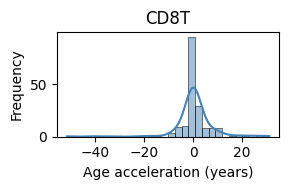

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = perturb_rr['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = perturb_rr[perturb_rr['cell_type'] == cell_type].copy()
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Significance of age acceleration per TF

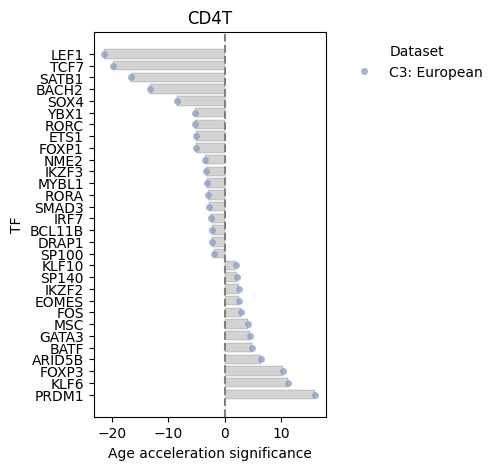

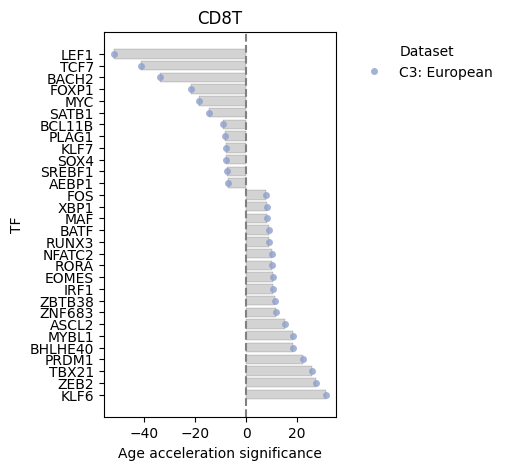

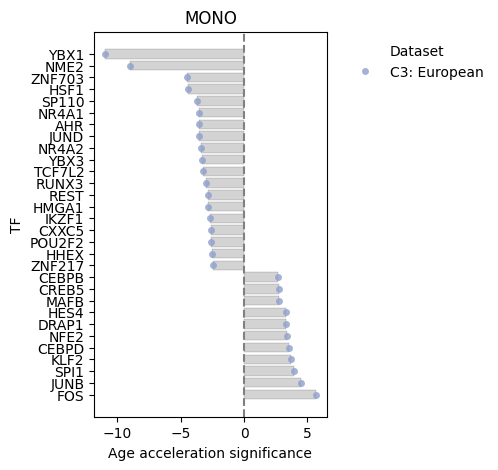

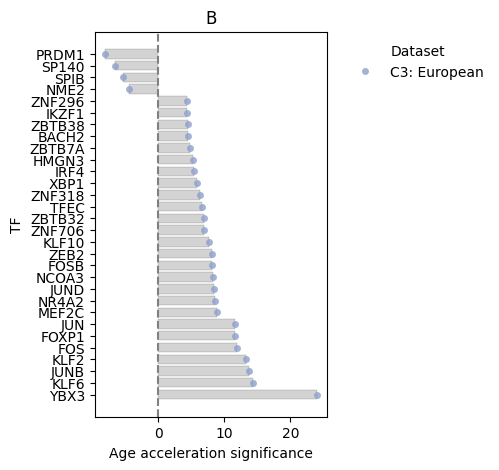

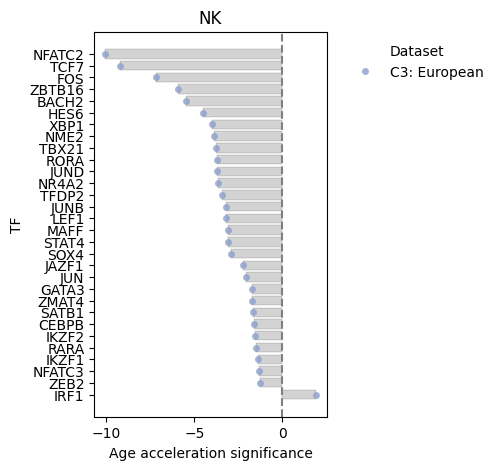

In [3]:
from ciim.src.insilico_perturbation.helper import wrapper_plot_age_acceleration_for_tf_perturbation

value_col= 'mean_diff'#'signed_neg_log10_pval'
features = None

for cell_type in perturb_rr['cell_type'].unique():
    perturb_rr_t = perturb_rr[perturb_rr['cell_type'] == cell_type]

    if False:
        # filter for sig aging TFs
        aging_stats = retrieve_sig_stats(type='bulk')
        aging_tfs = aging_stats[aging_stats['cell_type'] == cell_type]['tf'].unique()
        perturb_rr_t = perturb_rr_t[perturb_rr_t['tf'].isin(aging_tfs)]
    aa = wrapper_plot_age_acceleration_for_tf_perturbation(perturb_rr_t, value_col=value_col, top_n=30)
    plt.title(f"{cell_type}")

## Aging trends: verification

True
True
True
True
True


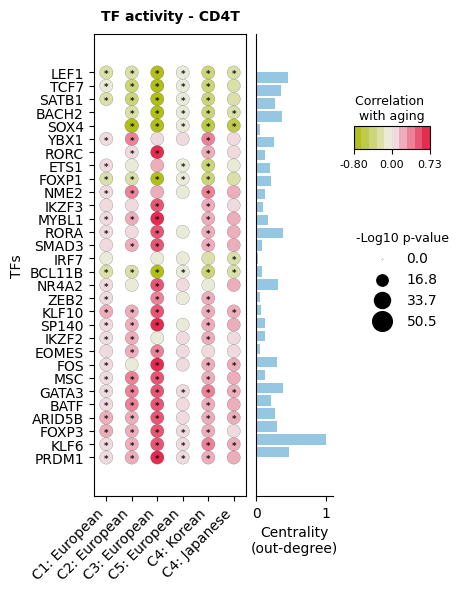

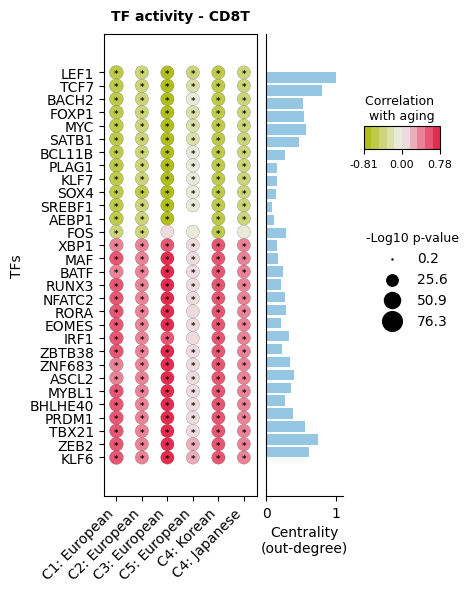

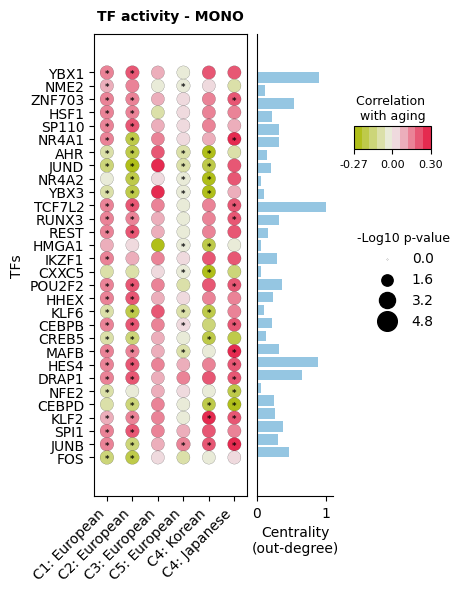

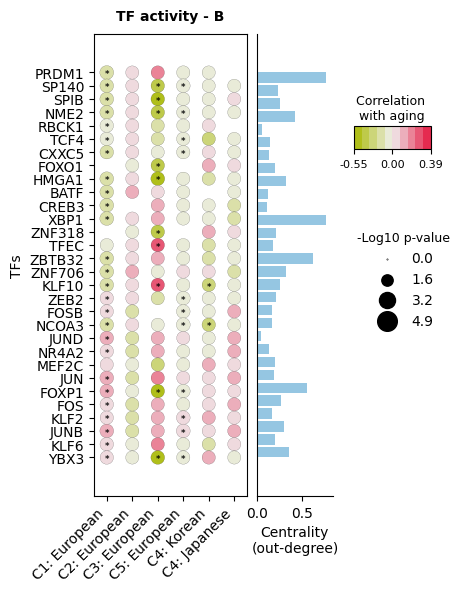

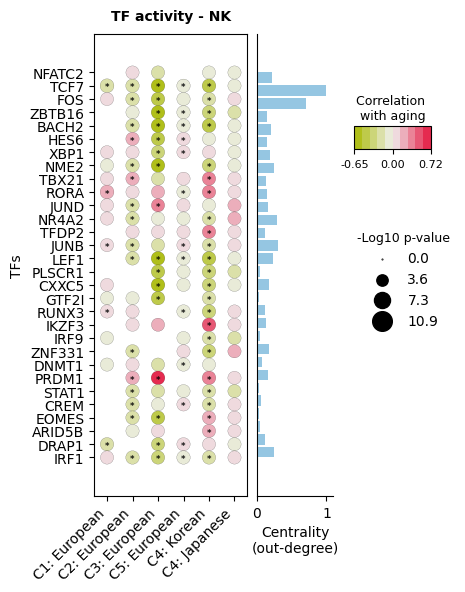

In [4]:
for cell_type in perturb_rr['cell_type'].unique():
    df_cell = perturb_rr[perturb_rr['cell_type'] == cell_type].copy()
    value_col = 'signed_neg_log10_pval'
    top_n = 30

    median_abs = df_cell.groupby('tf')[value_col].apply(lambda x: x.abs().median())
    top_tfs = median_abs.sort_values(ascending=False).head(top_n).index

    # Keep only top TFs
    df_cell = df_cell[df_cell['tf'].isin(top_tfs)].copy()

    # Sort TFs by signed mean_diff for plotting
    tf_order = df_cell.groupby('tf')[value_col].mean().sort_values().index
    df_cell['tf'] = pd.Categorical(df_cell['tf'], categories=tf_order, ordered=True)
    df_cell['tf'].cat.categories

    features = df_cell['tf'].cat.categories
    from ciim.src.tf_activity.plots import plot_features_vs_datasets
    bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': 0.1})

## Consistency of the age shift with aging TFs: verification 

In [5]:
# Import dependencies
from ciim.src.tf_activity.helper import retrieve_sig_stats

# Get the sign of slope for perturbation analysis
# perturb_rr_sig = perturb_rr[perturb_rr['signed_neg_log10_pval'].abs()>1.4]
perturb_slope_sign = (
    perturb_rr.groupby(['cell_type', 'tf'])['mean_diff']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'mean_diff': 'slope'})
)


# Get the sign of slope for aging TFs (reference)
stats = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])
aging_slope_sign = (
    stats.groupby(['cell_type', 'tf'])['slope']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'slope': 'slope'})
)

# Cell type-specific overlap
overlap_results = []

for cell_type in cell_types:
    # Subset aging (reference) and perturbation data
    aging_t = aging_slope_sign[aging_slope_sign['cell_type'] == cell_type]
    perturb_t = perturb_slope_sign[perturb_slope_sign['cell_type'] == cell_type]
    # Merge on TFs that are found in both
    merged = aging_t.merge(perturb_t, on='tf', suffixes=('_aging', '_perturb'), how='inner')

    if merged.empty:
        continue

    # Count matches with respect to aging slope
    matched = (merged['slope_aging'] == merged['slope_perturb']).sum()
    total = merged.shape[0]
    fraction_matched = matched / total

    overlap_results.append({
        'cell_type': cell_type,
        'n_ref_tfs': len(aging_t),
        'n_overlap_tfs': total,
        'n_matched': matched,
        'fraction_matched': fraction_matched
    })


overlap_df = pd.DataFrame(overlap_results)
overlap_df

,cell_type,n_ref_tfs,n_overlap_tfs,n_matched,fraction_matched
0,CD4T,57,57,37,0.649123
1,CD8T,165,162,143,0.882716
2,MONO,59,58,26,0.448276
3,B,9,8,6,0.750000
4,NK,30,28,17,0.607143


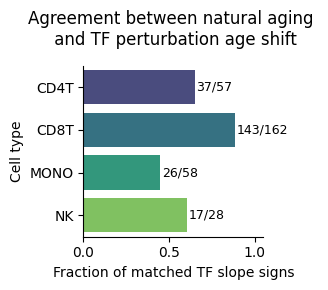

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tf_slope_overlap(overlap_df):
    fig, ax = plt.subplots(figsize=(3, 3))

    # Plot the bars
    barplot = sns.barplot(
        data=overlap_df,
        x='fraction_matched',
        y='cell_type',
        ax=ax,
        palette='viridis'
    )

    # Add text labels directly on the bars
    for bar, (_, row) in zip(barplot.patches, overlap_df.iterrows()):
        width = bar.get_width()
        y_center = bar.get_y() + bar.get_height() / 2
        label = f"{int(row['n_matched'])}/{int(row['n_overlap_tfs'])}"

        if width > 0.9:
            ax.text(width - 0.02, y_center, label, va='center', ha='right', fontsize=9, color='white')
        else:
            ax.text(width + 0.01, y_center, label, va='center', ha='left', fontsize=9, color='black')

    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Fraction of matched TF slope signs')
    ax.set_ylabel('Cell type')
    ax.set_title('Agreement between natural aging \n and TF perturbation age shift', pad=15)
    sns.despine()
    plt.tight_layout()
    return fig

# Usage
aa = plot_tf_slope_overlap(overlap_df[overlap_df['cell_type'].isin(['CD4T', 'CD8T', 'MONO', 'NK'])])

## Repo: Donor level plot

In [93]:
if False:
    from ciim.src.insilico_perturbation.helper import perform_stat_test, plot_age_acceleration_donors
    # format the data for test
    cell_type = 'MONO'
    dataset = 'data12'
    ctr='Unperturbed'
    treatment='Perturbed'

    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df_pivot, ctr=ctr, treatment=treatment)


# Combinatorial perturbation

In [23]:
from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening, plot_age_acceleration

## Aging TFs and simulated overall age shift

In [24]:
par = {
    'years': 10,
    'n_donors': 1,
    'data_type': 'bulk',
    'version': 'v1.0',
    'reg_type': 'ridge',
    'feature_type': 'gene_expression',
    'perturbation_mode': 'natural_aging',
    'perturbation_type': 'multi',
    'tfs': 'aging',
}
df_all = wrapper_run_tf_screening(par, 
                            n_jobs=1,
                            cell_types=cell_types,
                            datasets=datasets_all,
                            )


Processing: CD4T - data1 (natural_aging | multi)
Processing: CD4T - data7_allTPs_jalil (natural_aging | multi)
Processing: CD4T - data12 (natural_aging | multi)
Processing: CD4T - SLE_European (natural_aging | multi)
Processing: CD4T - data13_Korean (natural_aging | multi)
Processing: CD4T - data13_Japanese (natural_aging | multi)
Processing: CD8T - data1 (natural_aging | multi)
Processing: CD8T - data7_allTPs_jalil (natural_aging | multi)
Processing: CD8T - data12 (natural_aging | multi)
Processing: CD8T - SLE_European (natural_aging | multi)
Processing: CD8T - data13_Korean (natural_aging | multi)
Processing: CD8T - data13_Japanese (natural_aging | multi)
Processing: MONO - data1 (natural_aging | multi)
Processing: MONO - data7_allTPs_jalil (natural_aging | multi)
Processing: MONO - data12 (natural_aging | multi)
Processing: MONO - SLE_European (natural_aging | multi)
Processing: MONO - data13_Korean (natural_aging | multi)
Processing: MONO - data13_Japanese (natural_aging | multi)
P

Text(0.5, 1.0, 'Combinatorial perturbation of aging TFs\n (natural aging mode)')

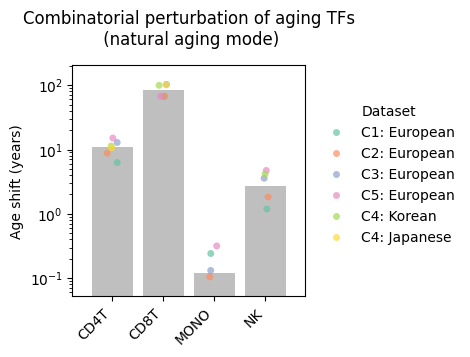

In [28]:
fig = plot_age_acceleration(df_all[df_all['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], log_y=True)
plt.title('Combinatorial perturbation of aging TFs\n (natural aging mode)', pad=15)

## Disease

In [31]:
def retrieve_sig_stats_disease(dataset='', feature_type='tf_activity', test_type='unpaired', type='bulk'):
    # - retrieve stats of tf association with drugs
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    stats_disease_sig = stats_drug[(stats_drug['p_value_adj']< 0.05) & (stats_drug['age_group']=='Both age groups') ].copy()
    return stats_disease_sig
def get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig):
    # - retrieve sig stats
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_disease_sig = stats_disease_sig[['cell_type', 'tf', 'slope_condition']].drop_duplicates(subset=['cell_type', 'tf'])

    stats_both = stats_aging_sig.merge(stats_disease_sig, on=['cell_type', 'tf'], how='inner')

    # - find the overlapping tfs
    print(stats_both.groupby('cell_type').size())

    # - get the slop of the overlapping tfs
    df_slope = stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]
    return df_slope
# - SLE
dataset = 'SLE_European' #'SLE_European' Covid_50MHH
stats_disease_sig = retrieve_sig_stats_disease(dataset=dataset)  
slope_df = get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig)
slope_df.head()

cell_type
B        5
CD4T    24
CD8T    85
MONO     6
NK      17
dtype: int64


,slope,cell_type
tf,,
ARID5B,2.726685,CD4T
BATF,2.110205,CD4T
BCL11B,-0.198362,CD4T
BHLHE40,0.730378,CD4T
ELF1,0.603330,CD4T


In [32]:
from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening, plot_age_acceleration
par = {
    'years': 10,
    'n_donors': 1,
    'data_type': 'bulk',
    'version': 'v1.0',
    'reg_type': 'ridge',
    'feature_type': 'gene_expression',
    'perturbation_mode': None,
    'perturbation_type': 'multi',
    'slope_df': slope_df,
}
df_all = wrapper_run_tf_screening(par, 
                            n_jobs=1,
                            cell_types=cell_types,
                            datasets=datasets_all,
                            )

Processing: CD4T - data1 (None | multi)
Processing: CD4T - data7_allTPs_jalil (None | multi)
Processing: CD4T - data12 (None | multi)
Processing: CD4T - SLE_European (None | multi)
Processing: CD4T - data13_Korean (None | multi)
Processing: CD4T - data13_Japanese (None | multi)
Processing: CD8T - data1 (None | multi)
Processing: CD8T - data7_allTPs_jalil (None | multi)
Processing: CD8T - data12 (None | multi)
Processing: CD8T - SLE_European (None | multi)
Processing: CD8T - data13_Korean (None | multi)
Processing: CD8T - data13_Japanese (None | multi)
Processing: MONO - data1 (None | multi)
Processing: MONO - data7_allTPs_jalil (None | multi)
Processing: MONO - data12 (None | multi)
Processing: MONO - SLE_European (None | multi)
Processing: MONO - data13_Korean (None | multi)
Processing: MONO - data13_Japanese (None | multi)
Processing: B - data1 (None | multi)
Processing: B - data7_allTPs_jalil (None | multi)
Processing: B - data12 (None | multi)
Processing: B - SLE_European (None | m

Text(0.5, 1.0, 'Perturbation of aging TFs \n associated with SLE disease')

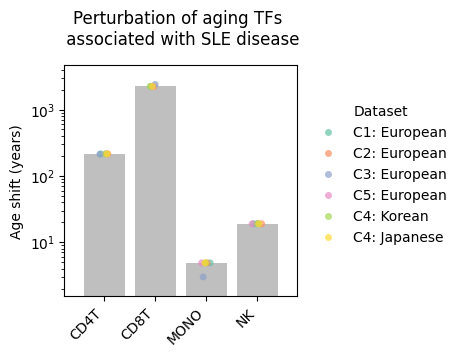

In [34]:
fig = plot_age_acceleration(df_all[df_all['cell_type'].isin(['CD8T', 'CD4T', 'NK', 'MONO'])], log_y=True)
plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)

## Drug perturbation

In [35]:
def retrieve_sig_stats_drug(feature_type='tf_activity', dataset='CXCL9', test_type='paired', type='bulk'):
    # - retrieve stats of tf association with drugs
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    stats_drug_sig = stats_drug[(stats_drug['p_value_adj']< 0.05)].copy()
    return stats_drug_sig
def get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig):
    # - retrieve sig stats
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_drug_sig = stats_drug_sig[['cell_type', 'tf', 'slope_condition', 'comparision']].drop_duplicates(subset=['cell_type', 'tf', 'comparision'])

    stats_both = stats_aging_sig.merge(stats_drug_sig, on=['cell_type', 'tf'], how='inner')

    # - find the overlapping tfs
    print(stats_both.groupby(['cell_type', 'comparision']).size())

    # - get the slop of the overlapping tfs
    df_slope = stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]
    return df_slope
stats_drug_sig = retrieve_sig_stats_drug(dataset='CXCL9')
df_slope = get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig)
df_slope.head()

cell_type  comparision            
B          Metformin (ctr: RPMI)       3
           Ruxolitinib (ctr: RPMI)     1
CD4T       LPS (ctr: RPMI)            27
           Ruxolitinib (ctr: LPS)      1
CD8T       LPS (ctr: RPMI)            66
           Ruxolitinib (ctr: LPS)     27
           Ruxolitinib (ctr: RPMI)     1
MONO       LPS (ctr: RPMI)            17
           Metformin (ctr: LPS)       13
           Metformin (ctr: RPMI)      12
           Ruxolitinib (ctr: LPS)     19
           Ruxolitinib (ctr: RPMI)    15
NK         LPS (ctr: RPMI)            17
           Ruxolitinib (ctr: LPS)     17
dtype: int64


,slope,cell_type,comparision
tf,,,
BATF,1.244168,CD4T,LPS (ctr: RPMI)
BCL11B,-12.912138,CD4T,LPS (ctr: RPMI)
CREB3L2,-0.601455,CD4T,LPS (ctr: RPMI)
FOXP1,-28.404285,CD4T,LPS (ctr: RPMI)
IRF7,-0.803658,CD4T,Ruxolitinib (ctr: LPS)


In [36]:
if True:
    df_store = []
    for comparision in df_slope['comparision'].unique():
        df_slope_c = df_slope[df_slope['comparision'] == comparision].copy()

        from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening, plot_age_acceleration
        par = {
            'years': 10,
            'n_donors': 1,
            'data_type': 'bulk',
            'version': 'v1.0',
            'reg_type': 'ridge',
            'feature_type': 'gene_expression',
            'perturbation_mode': None,
            'perturbation_type': 'multi',
            'slope_df': df_slope_c,
        }
        df_all_c = wrapper_run_tf_screening(par, 
                                    n_jobs=1,
                                    cell_types=cell_types,
                                    datasets=datasets_all,
                                    )
        df_all_c['comparision'] = comparision
        df_store.append(df_all_c)
    df_all = pd.concat(df_store)
    df_all.to_csv(f"{save_dir}/perturbation/tf_screen_results_drug_perturbation.csv", index=False)
else:
    df_all = pd.read_csv(f"{save_dir}/perturbation/tf_screen_results_drug_perturbation.csv")

Processing: CD4T - data1 (None | multi)
Processing: CD4T - data7_allTPs_jalil (None | multi)
Processing: CD4T - data12 (None | multi)
Processing: CD4T - SLE_European (None | multi)
Processing: CD4T - data13_Korean (None | multi)
Processing: CD4T - data13_Japanese (None | multi)
Processing: CD8T - data1 (None | multi)
Processing: CD8T - data7_allTPs_jalil (None | multi)
Processing: CD8T - data12 (None | multi)
Processing: CD8T - SLE_European (None | multi)
Processing: CD8T - data13_Korean (None | multi)
Processing: CD8T - data13_Japanese (None | multi)
Processing: MONO - data1 (None | multi)
Processing: MONO - data7_allTPs_jalil (None | multi)
Processing: MONO - data12 (None | multi)
Processing: MONO - SLE_European (None | multi)
Processing: MONO - data13_Korean (None | multi)
Processing: MONO - data13_Japanese (None | multi)
Processing: B - data1 (None | multi)
Processing: B - data7_allTPs_jalil (None | multi)
Processing: B - data12 (None | multi)
Processing: B - SLE_European (None | m

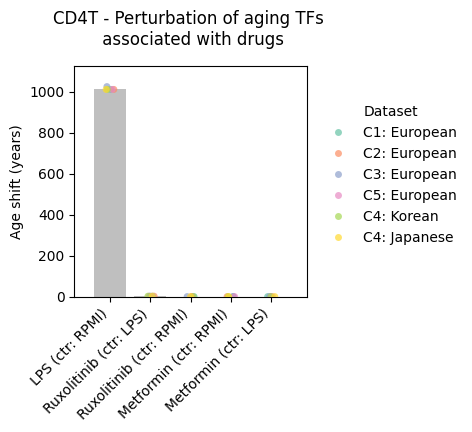

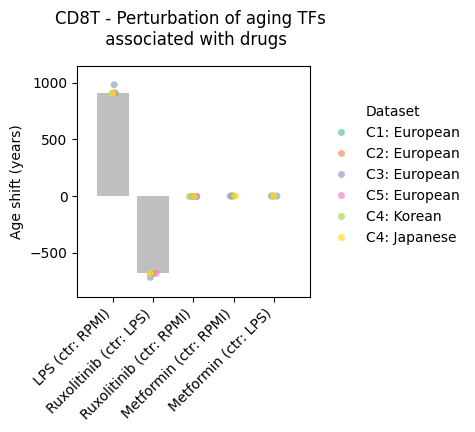

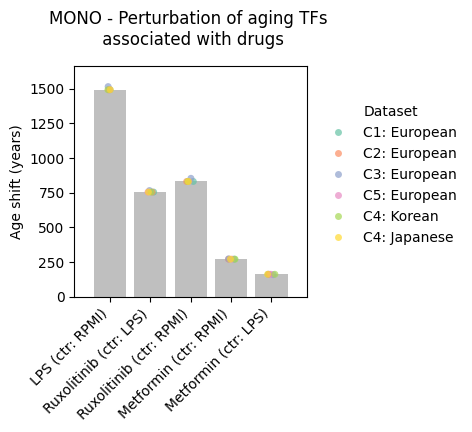

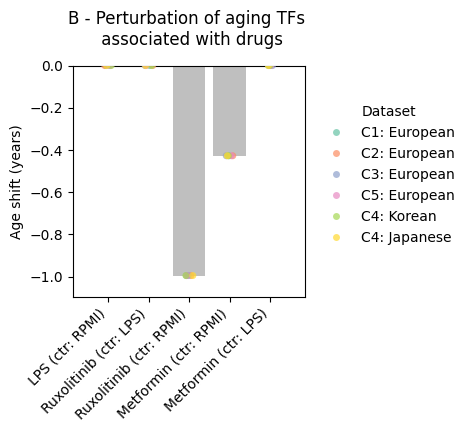

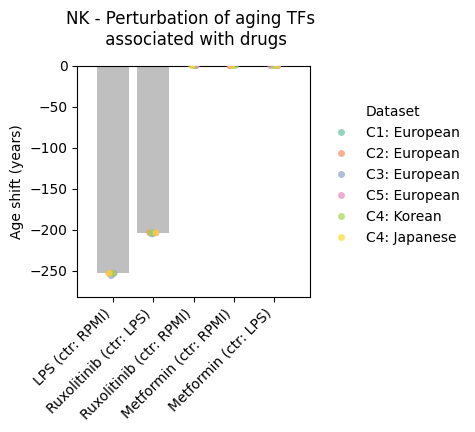

In [39]:
for cell_type in df_all['cell_type'].unique():
    df = df_all[df_all['cell_type'] == cell_type].copy()
    plot_age_acceleration(df, x_col='comparision')
    plt.title(f"{cell_type} - Perturbation of aging TFs \n associated with drugs", pad=15)
